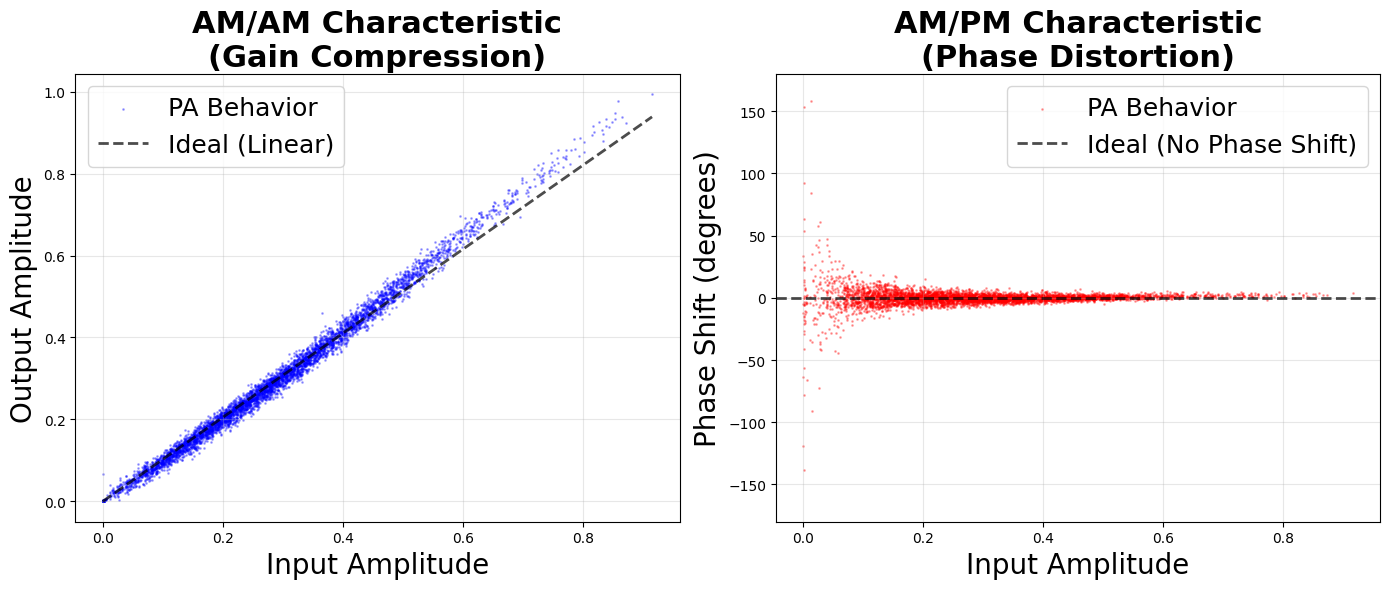


=== PA Characteristic Summary ===
Input amplitude range: 0.0000 to 0.9157
Output amplitude range: 0.0001 to 0.9934
Estimated small-signal gain: 1.0248
Phase distortion range: -209.73° to 158.56°
80000


In [28]:
from sparseDPD import DataManager, PNTDNN_NeuralNetwork, Volterra, LinearExperiment, AdaptivePruningExperiment

# Load the ideal predistorted signal, and plot
ideal_predistored_dataset = DataManager(num_training_points=50000, num_test_points=5000, num_validaiton_points=5000, filepath='100M_9.5PAPR.mat')

ideal_predistored_dataset.plot_pa_characteristics()

print(len(ideal_predistored_dataset.input_data))

In [29]:
# Print Volterra Performance
volterra_forward_model = Volterra(num_nl_orders=3, num_memory_levels=15, dataset=ideal_predistored_dataset.training_dataset)

print(f" Volterra NMSE: {volterra_forward_model.calculate_volterra_nmse(ideal_predistored_dataset.test_dataset)} dB")

 Volterra NMSE: -38.83018925323994 dB


In [30]:
# Model the ideal predistorted (This will actually be modelled as a forward model)
pntdnn_ideal_predistorted = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True)

# train this model
pntdnn_ideal_predistorted.get_best_model(
    num_epochs = 500,
    training_dataset=ideal_predistored_dataset.training_dataset,
    validation_dataset=ideal_predistored_dataset.validation_dataset
)

# Save the model, so it can be used later
pntdnn_ideal_predistorted.write_nn_to_file(file_path="pntdnn_ideal_predistorted_forward_model.pt")


Using cuda device
Epoch  10/500  Loss=3.7641e+02  Valid Loss=3.5669e+01  LR=1.00e-03  NMSE=-9.2399 dB
Epoch  20/500  Loss=7.6487e+01  Valid Loss=7.3900e+00  LR=1.00e-03  NMSE=-16.0764 dB
Epoch  30/500  Loss=2.8923e+01  Valid Loss=2.8324e+00  LR=1.00e-03  NMSE=-20.2413 dB
Epoch  40/500  Loss=1.3811e+01  Valid Loss=1.3860e+00  LR=1.00e-03  NMSE=-23.3453 dB
Epoch  50/500  Loss=9.4968e+00  Valid Loss=9.6267e-01  LR=1.00e-03  NMSE=-24.9281 dB
Epoch  60/500  Loss=7.3784e+00  Valid Loss=7.4852e-01  LR=1.00e-03  NMSE=-26.0208 dB
Epoch  70/500  Loss=5.8813e+00  Valid Loss=5.9508e-01  LR=1.00e-03  NMSE=-27.0171 dB
Epoch  80/500  Loss=4.7623e+00  Valid Loss=4.8095e-01  LR=1.00e-03  NMSE=-27.9418 dB
Epoch  90/500  Loss=3.8956e+00  Valid Loss=3.9377e-01  LR=1.00e-03  NMSE=-28.8104 dB
Epoch 100/500  Loss=3.2152e+00  Valid Loss=3.2479e-01  LR=1.00e-03  NMSE=-29.6468 dB
Epoch 110/500  Loss=2.6844e+00  Valid Loss=2.7036e-01  LR=1.00e-03  NMSE=-30.4434 dB
Epoch 120/500  Loss=2.2683e+00  Valid Loss=2.272

Using cuda device

Pruning Iteration 1/10
Pruning 20.0% of remaining weights...
Current pruning: 20.00% of weights are zero
Retraining for 100 epochs...
Epoch  10/100  Loss=2.7805e-01  Valid Loss=2.8660e-02  LR=1.00e-03  NMSE=-40.1901 dB
Epoch  20/100  Loss=2.4740e-01  Valid Loss=2.4561e-02  LR=1.00e-03  NMSE=-40.8603 dB
Epoch  30/100  Loss=2.5684e-01  Valid Loss=2.5634e-02  LR=1.00e-03  NMSE=-40.6747 dB
Epoch  40/100  Loss=2.4430e-01  Valid Loss=2.3942e-02  LR=1.00e-03  NMSE=-40.9712 dB
Epoch  50/100  Loss=2.3867e-01  Valid Loss=2.2941e-02  LR=1.00e-03  NMSE=-41.1567 dB
Epoch  60/100  Loss=2.3439e-01  Valid Loss=2.2436e-02  LR=1.00e-03  NMSE=-41.2533 dB
Epoch  70/100  Loss=2.3117e-01  Valid Loss=2.2023e-02  LR=1.00e-03  NMSE=-41.3340 dB
Epoch  80/100  Loss=2.2681e-01  Valid Loss=2.1454e-02  LR=1.00e-03  NMSE=-41.4478 dB
Epoch  90/100  Loss=2.2363e-01  Valid Loss=2.1006e-02  LR=1.00e-03  NMSE=-41.5394 dB
Epoch 100/100  Loss=2.1991e-01  Valid Loss=2.0588e-02  LR=1.00e-03  NMSE=-41.6267 

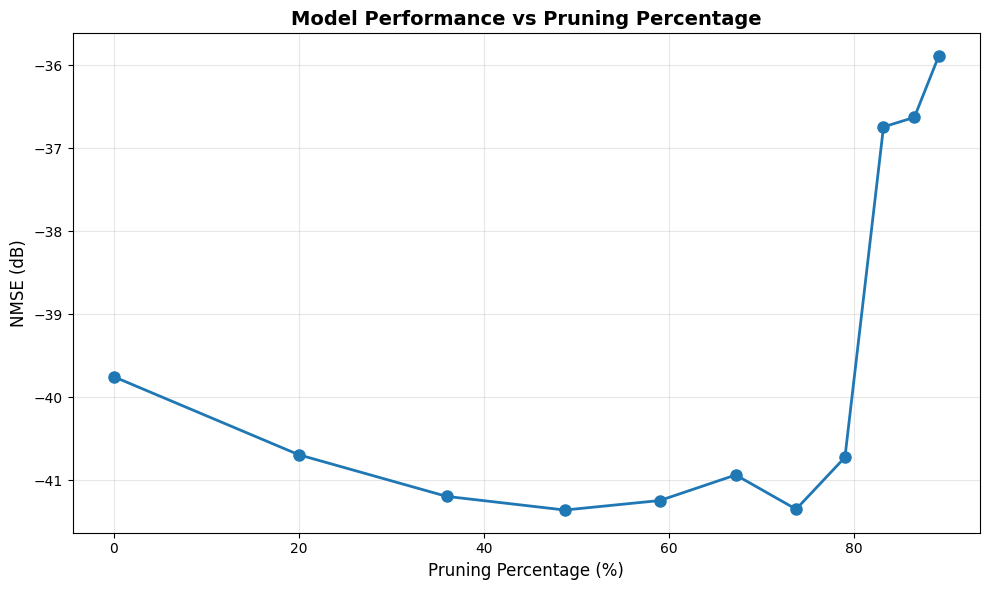

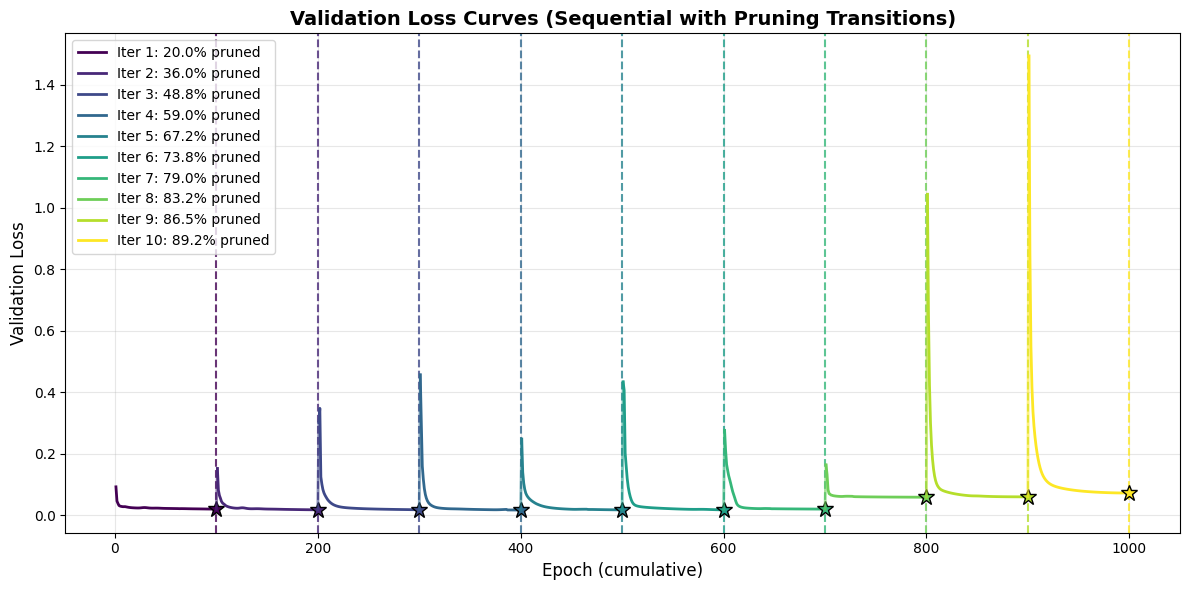

In [31]:
# Linearly prune the model
# Load the model
pntdnn_ideal_predistorted = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True, nn_file_path="pntdnn_ideal_predistorted_forward_model.pt")

pntdnn_ideal_pruning_experiment = LinearExperiment(
    nn_model= pntdnn_ideal_predistorted,
    num_prune_iterations=10,
    prune_amount=0.2,
    retrain_epochs=100,
    training_dataset=ideal_predistored_dataset.training_dataset,
    valid_dataset=ideal_predistored_dataset.validation_dataset,
    test_dataset=ideal_predistored_dataset.test_dataset,
    nmse_tolerance=-37
)
pntdnn_ideal_pruning_experiment.run()

# Save the best model
pntdnn_ideal_pruning_experiment.best_model.write_nn_to_file(file_path="pntdnn_ideal_predistorted_forward_model_linear_pruned.pt")

Using cuda device
Baseline NMSE          : -39.7535 dB
Tolerance              : +2.75 dB
NMSE must stay below   : -37.0000 dB
Initial prune fraction : 50.0%
Min prune fraction     : 1.0%
Max prune fraction     : 50.0%

Step 1  |  fraction = 50.00%
Pruning 50.00% of remaining weights...
Current sparsity: 50.00% of weights are zero
Retraining for 200 epochs...
Epoch  10/200  Loss=5.4605e-01  Valid Loss=5.2953e-02  LR=1.00e-03  NMSE=-37.5240 dB
Epoch  20/200  Loss=3.5035e-01  Valid Loss=3.4936e-02  LR=1.00e-03  NMSE=-39.3301 dB
Epoch  30/200  Loss=3.0726e-01  Valid Loss=3.0541e-02  LR=1.00e-03  NMSE=-39.9140 dB
Epoch  40/200  Loss=3.0164e-01  Valid Loss=3.0476e-02  LR=1.00e-03  NMSE=-39.9232 dB
Epoch  50/200  Loss=2.8882e-01  Valid Loss=2.8881e-02  LR=1.00e-03  NMSE=-40.1568 dB
Epoch  60/200  Loss=2.8045e-01  Valid Loss=2.8034e-02  LR=1.00e-03  NMSE=-40.2860 dB
Epoch  70/200  Loss=2.7305e-01  Valid Loss=2.7304e-02  LR=1.00e-03  NMSE=-40.4006 dB
Epoch  80/200  Loss=2.6677e-01  Valid Loss=2

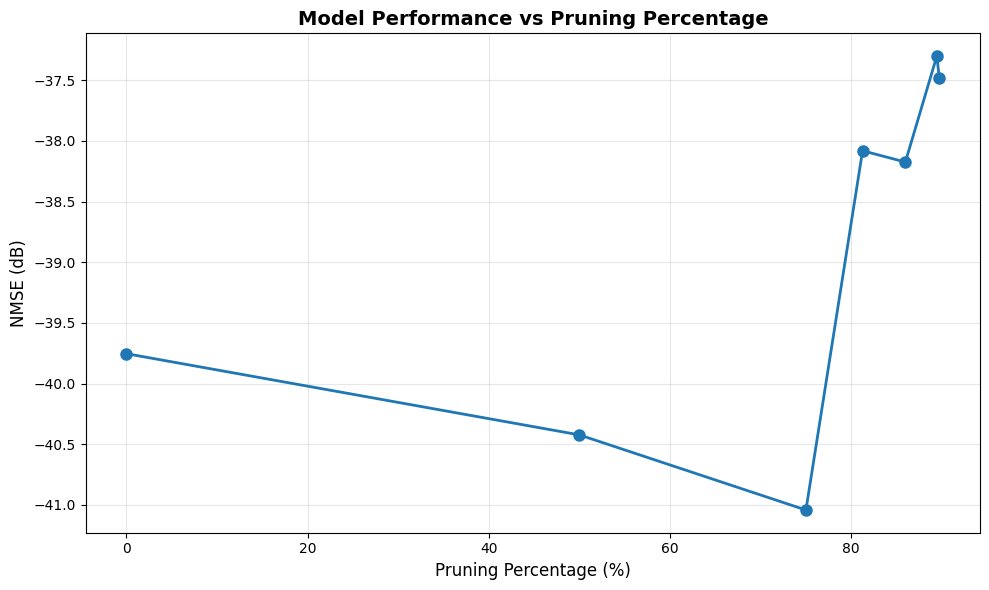

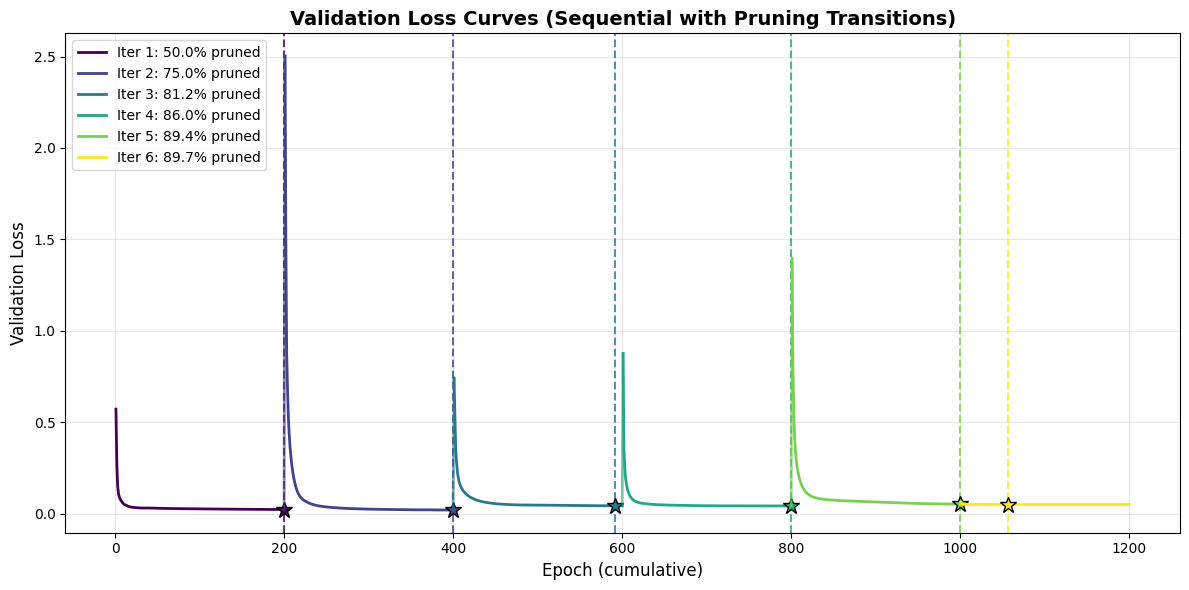

In [32]:
# Use adaptive pruning
pntdnn_ideal_predistorted = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True, nn_file_path="pntdnn_ideal_predistorted_forward_model.pt")

adaptive_pruning_experiment_PNTDNN = AdaptivePruningExperiment(
    nn_model=pntdnn_ideal_predistorted,
    retrain_epochs= 200,
    training_dataset = ideal_predistored_dataset.training_dataset,
    valid_dataset = ideal_predistored_dataset.validation_dataset,
    test_dataset = ideal_predistored_dataset.test_dataset,
    nmse_threshold = -37,
    initial_prune_fraction=0.5,
    min_prune_fraction=0.01,
    max_prune_fraction=0.5
)

adaptive_pruning_experiment_PNTDNN.run()

# Save the best model
adaptive_pruning_experiment_PNTDNN.best_model.write_nn_to_file(file_path="pntdnn_ideal_predistorted_forward_model_adaptive_pruned.pt")

In [33]:
# make .mat files for the best models, so they can be used in the future for physical testing
import scipy.io

num_memory_levels = 15
# Load original, adaptive and fixed pruning models
adaptive_model = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True, nn_file_path="pntdnn_ideal_predistorted_forward_model_adaptive_pruned.pt")
fixed_percent_model = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True, nn_file_path="pntdnn_ideal_predistorted_forward_model_linear_pruned.pt")
original_model = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True, nn_file_path="pntdnn_ideal_predistorted_forward_model.pt")

# Get the full input signal
full_input = ideal_predistored_dataset.input_data

# Generate outputs for each model
print("Generating outputs for each model...")
adaptive_output = adaptive_model.generate_model_output(full_input)
fixed_output = fixed_percent_model.generate_model_output(full_input)
original_output = original_model.generate_model_output(full_input)

# Save to .mat files with 'x' (input) and 'u' (output) naming convention
print("Saving .mat files...")
scipy.io.savemat('adaptive_pruned_output.mat', {'x1': full_input[num_memory_levels:], 'u': adaptive_output})
scipy.io.savemat('fixed_pruned_output.mat', {'x1': full_input[num_memory_levels:], 'u': fixed_output})
scipy.io.savemat('original_model_output.mat', {'x1': full_input[num_memory_levels:], 'u': original_output})

print("✓ Saved adaptive_pruned_output.mat")
print("✓ Saved fixed_pruned_output.mat")
print("✓ Saved original_model_output.mat")

Using cuda device
Using cuda device
Using cuda device
Generating outputs for each model...
Saving .mat files...
✓ Saved adaptive_pruned_output.mat
✓ Saved fixed_pruned_output.mat
✓ Saved original_model_output.mat


In [34]:
# Optionally save Volterra model output as well
volterra_output = volterra_forward_model.generate_model_output(full_input)
scipy.io.savemat('volterra_output.mat', {'x1': full_input[num_memory_levels:], 'u': volterra_output})
print("✓ Saved volterra_output.mat")

✓ Saved volterra_output.mat


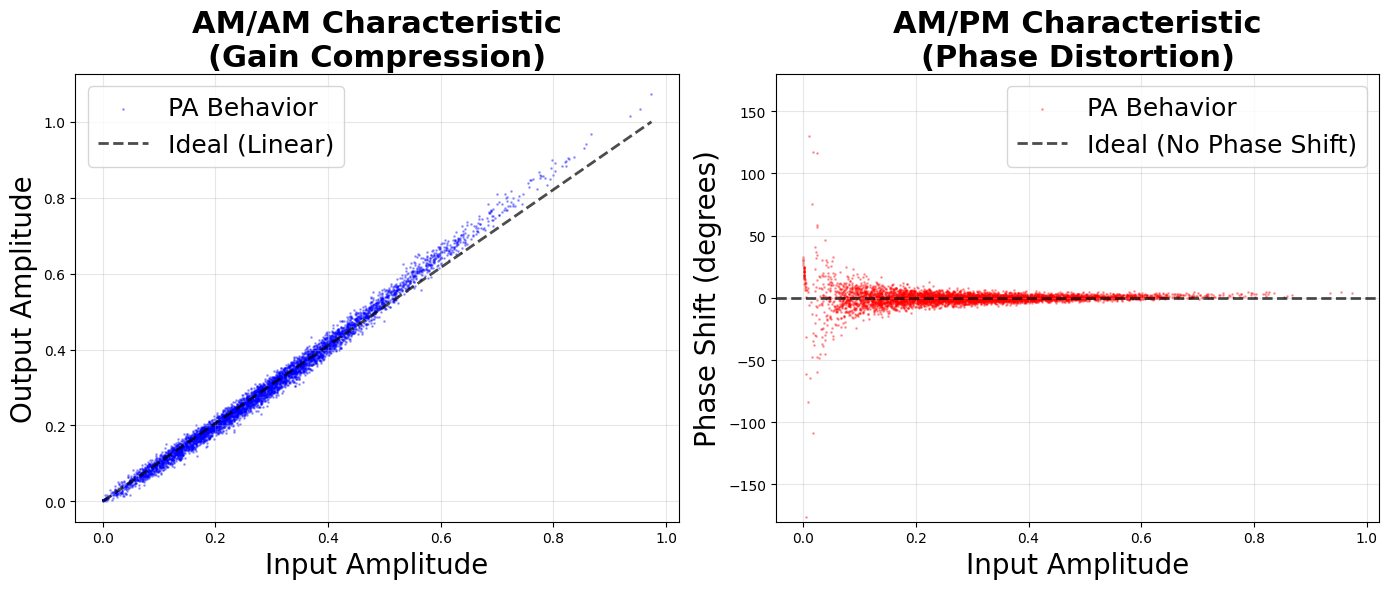


=== PA Characteristic Summary ===
Input amplitude range: 0.0001 to 0.9739
Output amplitude range: 0.0019 to 1.0727
Estimated small-signal gain: 1.0270
Phase distortion range: -176.07° to 130.16°


In [35]:
test = DataManager(num_training_points=50000, num_test_points=5000, num_validaiton_points=5000, filepath='fixed_pruned_output.mat')

test.plot_pa_characteristics()